In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(color_codes=True)

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path='/content/drive/MyDrive/ChronicKidneyDisease.csv'
df=pd.read_csv(file_path)
print(df)

       Bp     Sg   Al   Su  Rbc    Bu   Sc     Sod   Pot  Hemo    Wbcc  Rbcc  \
0    80.0  1.020  1.0  0.0  1.0  36.0  1.2  137.53  4.63  15.4  7800.0  5.20   
1    50.0  1.020  4.0  0.0  1.0  18.0  0.8  137.53  4.63  11.3  6000.0  4.71   
2    80.0  1.010  2.0  3.0  1.0  53.0  1.8  137.53  4.63   9.6  7500.0  4.71   
3    70.0  1.005  4.0  0.0  1.0  56.0  3.8  111.00  2.50  11.2  6700.0  3.90   
4    80.0  1.010  2.0  0.0  1.0  26.0  1.4  137.53  4.63  11.6  7300.0  4.60   
..    ...    ...  ...  ...  ...   ...  ...     ...   ...   ...     ...   ...   
395  80.0  1.020  0.0  0.0  1.0  49.0  0.5  150.00  4.90  15.7  6700.0  4.90   
396  70.0  1.025  0.0  0.0  1.0  31.0  1.2  141.00  3.50  16.5  7800.0  6.20   
397  80.0  1.020  0.0  0.0  1.0  26.0  0.6  137.00  4.40  15.8  6600.0  5.40   
398  60.0  1.025  0.0  0.0  1.0  50.0  1.0  135.00  4.90  14.2  7200.0  5.90   
399  80.0  1.025  0.0  0.0  1.0  18.0  1.1  141.00  3.50  15.8  6800.0  6.10   

     Htn  Class  
0    1.0      1  
1  

<Axes: >

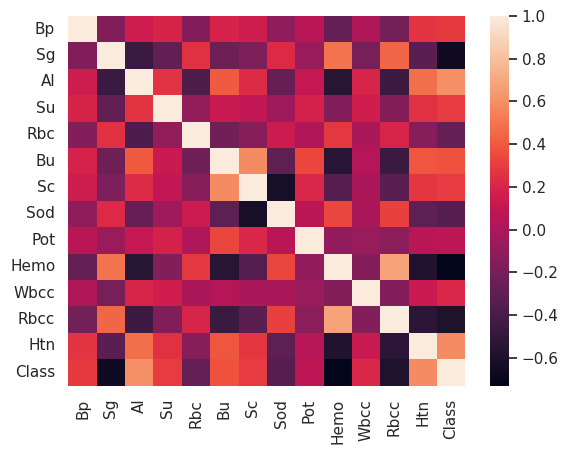

In [ ]:
sns.heatmap(df.corr(),fmt='.2g')

<Axes: xlabel='Bp', ylabel='Htn'>

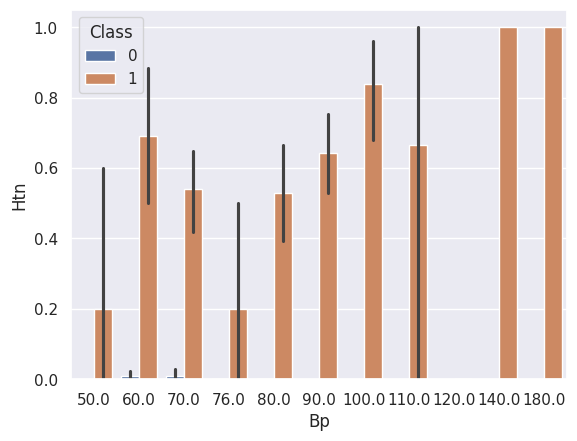

In [ ]:
sns.barplot(data=df, x="Bp",y="Htn", hue="Class")

<Axes: xlabel='Rbcc', ylabel='count'>

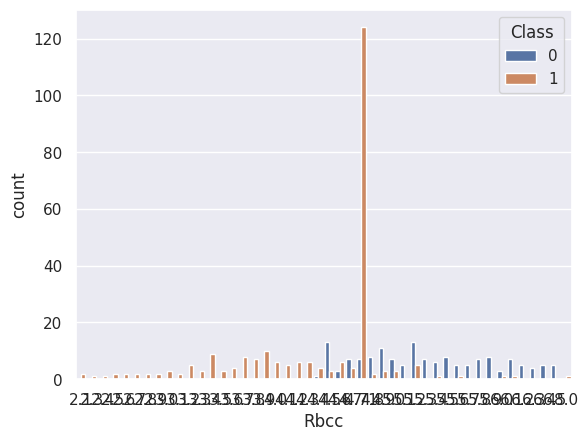

In [ ]:
sns.countplot(data=df, x='Rbcc', hue="Class")

/tmp/ipykernel_1041/4191300843.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Hemo', palette='Set2')


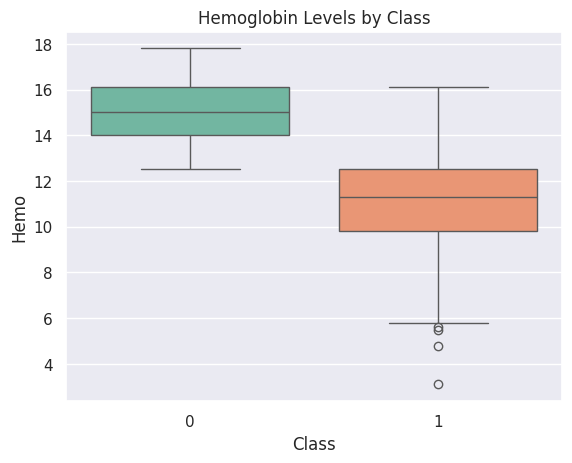

In [ ]:

sns.boxplot(data=df, x='Class', y='Hemo', palette='Set2')
plt.title('Hemoglobin Levels by Class')
plt.show()

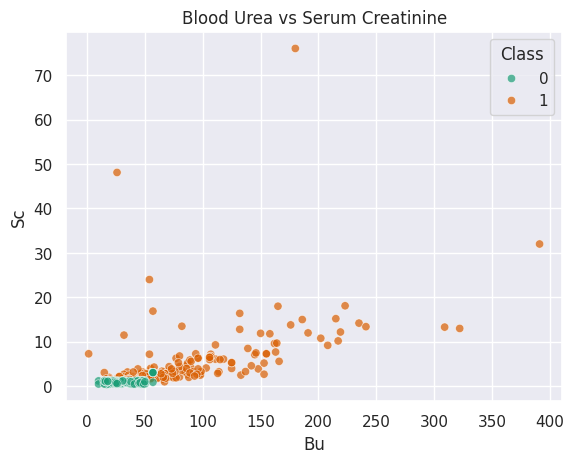

In [ ]:

sns.scatterplot(data=df, x='Bu', y='Sc', hue='Class', palette='Dark2', alpha=0.7)
plt.title('Blood Urea vs Serum Creatinine')
plt.show()

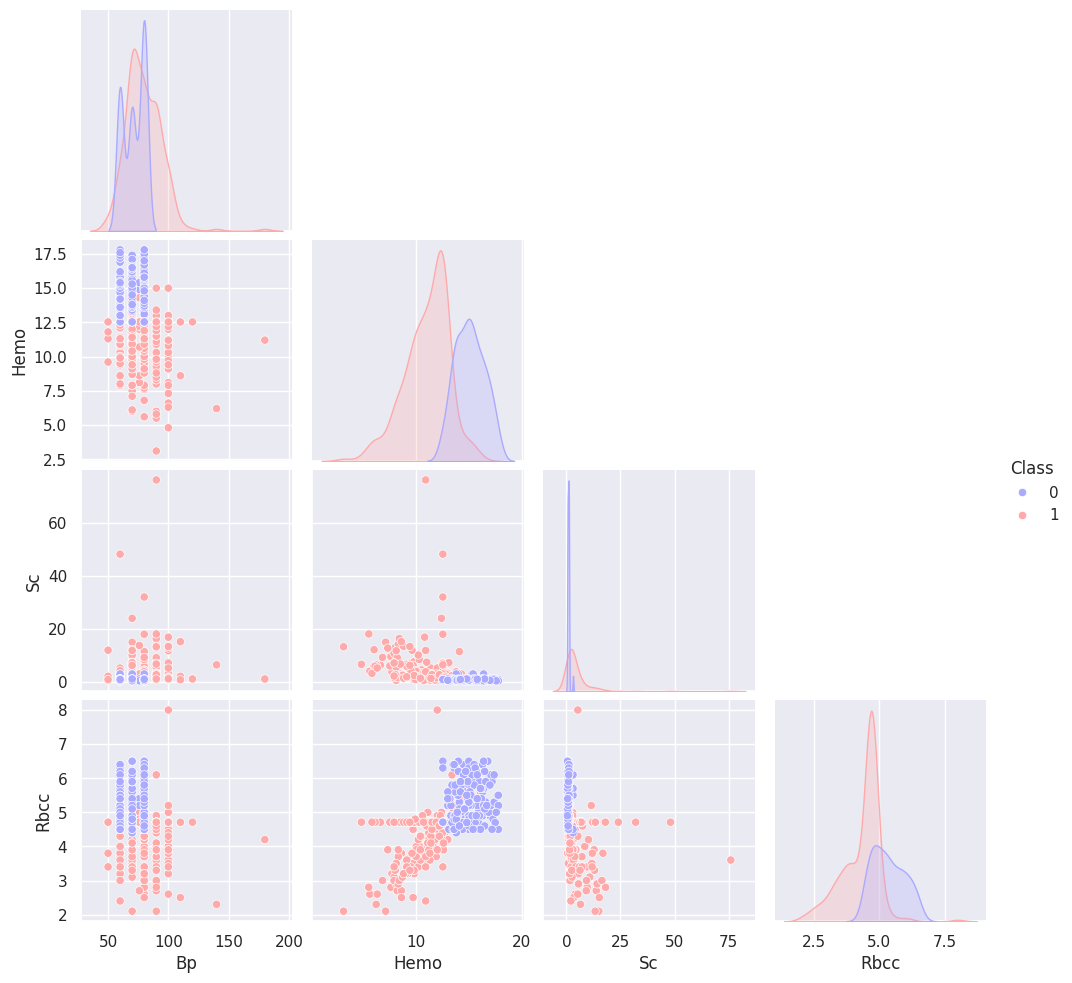

In [ ]:

key_features = ['Bp', 'Hemo', 'Sc', 'Rbcc', 'Class']
sns.pairplot(df[key_features], hue='Class', palette='bwr', corner=True)
plt.show()

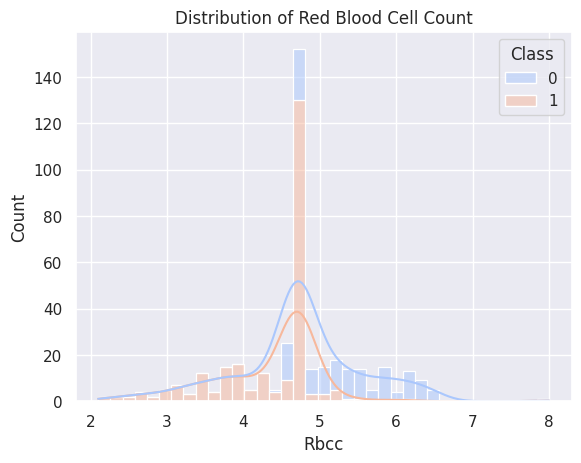

In [ ]:
# Distribution of Red Blood Cell Count split by Disease Class
sns.histplot(data=df, x='Rbcc', hue='Class', kde=True, multiple='stack', palette='coolwarm')
plt.title('Distribution of Red Blood Cell Count')
plt.show()

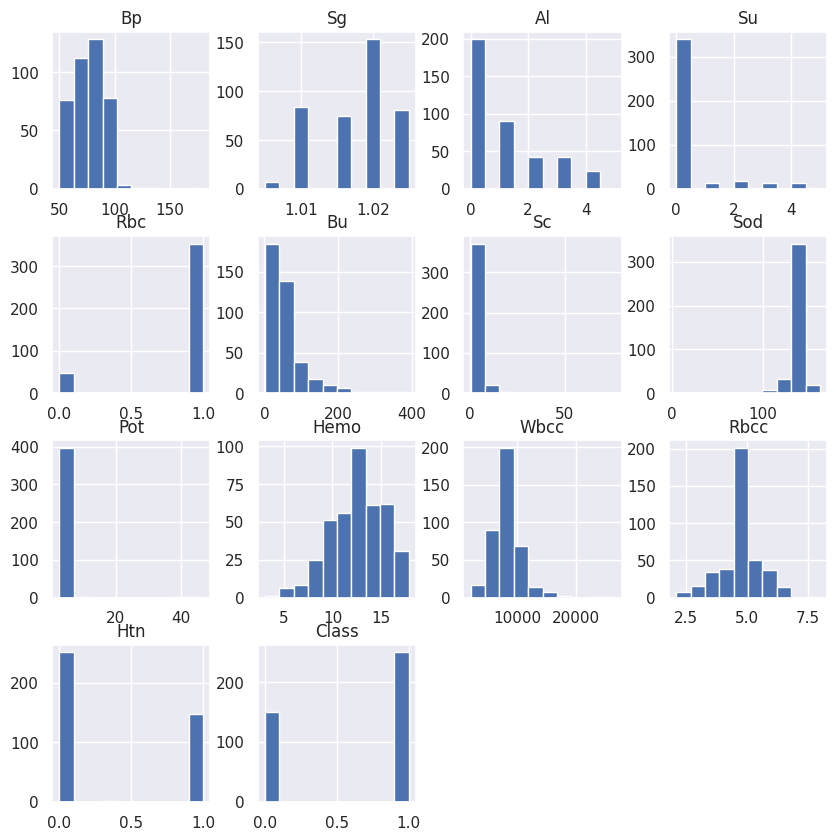

In [ ]:
df.hist(figsize=(10,10))
plt.show()

In [ ]:
df.dtypes

,0
Bp,float64
Sg,float64
Al,float64
Su,float64
Rbc,float64
Bu,float64
Sc,float64
Sod,float64
Pot,float64
Hemo,float64


In [ ]:
X = df.drop(columns=['Class'])
y = df['Class']

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score

# Now X and y exist!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Use Classifier instead of Regressor for binary targets
dtree = DecisionTreeClassifier(random_state=0)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
y_pred = dtree.predict(X_test)

In [ ]:
from sklearn import metrics
import math

mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = math.sqrt(mse)

print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))
print('RMSE score is {}'.format(rmse))

MAE is 0.0125
MSE is 0.0125
R2 score is 0.945054945054945
RMSE score is 0.11180339887498948


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [ ]:
from sklearn import metrics
import math
y_pred = rf.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = math.sqrt(mse)

print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))
print('RMSE score is {}'.format(rmse))

MAE is 0.017750000000000005
MSE is 0.0044475
R2 score is 0.9804505494505494
RMSE score is 0.06668957939588463


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
ada = AdaBoostRegressor(random_state=0)
ada.fit(X_train, y_train)

AdaBoostRegressor(random_state=0)

In [ ]:
from sklearn import metrics
import math
y_pred = ada.predict(X_test)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = math.sqrt(mse)

print('MAE is {}'.format(mae))
print('MSE is {}'.format(mse))
print('R2 score is {}'.format(r2))
print('RMSE score is {}'.format(rmse))

MAE is 0.015864158414527263
MSE is 0.0013049776045229496
R2 score is 0.9942638347053936
RMSE score is 0.03612447376119062
